# Lab 4: Hayashi-Yoshida estimator and Hawkes Processes

In this notebook, we analyze high-frequency data using the Hayashi-Yoshida estimator and Hawkes processes.

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from scipy.optimize import minimize
from scipy.stats import kstest
import scipy.stats as stats
from collections import defaultdict

## 1. Brownian motions with Poisson sampling

We use again the parameters of simulation we have take in the Lab 3

In [3]:
rng = np.random.default_rng(42)

T = 23400
TAUS = np.array([1, 5, 10, 30, 60, 120, 300, 600, 900, 1800])
N_PATHS = 300

SIMULATIONS = [
    {"mu1": 10.0, "mu2": 8.0,  "sigma1": 0.02 / np.sqrt(T), "sigma2": 0.015 / np.sqrt(T), "rho": 0.7},
    {"mu1": 5.0,  "mu2": 3.0,  "sigma1": 0.03 / np.sqrt(T), "sigma2": 0.025 / np.sqrt(T), "rho": 0.5},
    {"mu1": 20.0, "mu2": 15.0, "sigma1": 0.01 / np.sqrt(T), "sigma2": 0.012 / np.sqrt(T), "rho": 0.9},
]

Here, we simulate the trajectories of correlated assets using the given parameters, generating correlated increments via Cholesky decomposition. We then obtain the observation times from homogeneous Poisson processes.

In [4]:
def simulate_path(T, sigma1, sigma2, rho, mu1, mu2, dt_fine=0.1):
    n = int(T / dt_fine)
    ts = np.arange(n + 1) * dt_fine

    dW1 = rng.standard_normal(n) * np.sqrt(dt_fine)
    dW2 = rho * dW1 + np.sqrt(1 - rho**2) * rng.standard_normal(n) * np.sqrt(dt_fine)

    p1 = np.concatenate([[0.0], np.cumsum(sigma1 * dW1)])
    p2 = np.concatenate([[0.0], np.cumsum(sigma2 * dW2)])

    def poisson_times(mu, T):
        times = [0.0]
        while times[-1] < T:
            times.append(times[-1] + rng.exponential(1.0 / mu))
        return np.array(times[1:])

    t1 = poisson_times(mu1, T)
    t2 = poisson_times(mu2, T)
    t1 = t1[t1 <= T]
    t2 = t2[t2 <= T]

    idx1 = np.clip(np.searchsorted(ts, t1, side='right') - 1, 0, n)
    idx2 = np.clip(np.searchsorted(ts, t2, side='right') - 1, 0, n)

    return t1, p1[idx1], t2, p2[idx2]

This function estimates the realized covariance between two asynchronously observed price series by synchronizing them on a regular grid (step $\tau$) using previous-tick interpolation.

We simulate $N=300$ paths of two correlated log-prices $p_i(t)=\sigma_i W_i(t)$ with correlation $\rho=0.7$, observed at Poisson arrival times with intensities $\mu_1=10$/s and $\mu_2=8$/s over $T=23{,}400$ s. The theoretical quadratic covariation is $[p_1,p_2]_T = \rho \sigma_1 \sigma_2 T \approx 2.10 \times 10^{-4}$. For each $\tau$, the realized covariance is computed after synchronization.

But we see in the course that this kind of estimating the covariance introduce a biais, the Epps effect.

In [5]:
def realised_cov_refresh_time(t1, p1, t2, p2, tau, T):
    grid = np.arange(0, T + tau, tau)
    if len(grid) < 2:
        return np.nan

    def sync(t_obs, p_obs, grid):
        out = np.empty(len(grid))
        for i, g in enumerate(grid):
            idx = np.searchsorted(t_obs, g, side='right') - 1
            out[i] = p_obs[idx] if idx >= 0 else 0.0
        return out

    p1s = sync(t1, p1, grid)
    p2s = sync(t2, p2, grid)
    return np.sum(np.diff(p1s) * np.diff(p2s))

However, synchronization on a regular grid introduces a bias known as the Epps effect.

To address this issue, we use the Hayashi-Yoshida estimator, which is specifically designed for asynchronously observed processes.

We consider two log-price processes observed at random (Poisson) times:
- $X$ at times $t_i$
- $Y$ at times $s_j$

Define the increments over intervals:
$$
\Delta X_i = X_{t_i} - X_{t_{i-1}}, \quad \Delta Y_j = Y_{s_j} - Y_{s_{j-1}}
$$

and the associated intervals:
$$
I_i = (t_{i-1}, t_i], \quad J_j = (s_{j-1}, s_j]
$$

The Hayashi-Yoshida estimator of the quadratic covariation is given by:
$$
\widehat{[X,Y]}_T = \sum_{i,j} \Delta X_i \, \Delta Y_j \; \mathbf{1}_{\{ I_i \cap J_j \neq \varnothing \}}
$$

**Interpretation:** increments are multiplied only when their observation intervals overlap.

**Why it works:** in our setting, the log-prices follow correlated Brownian motions,
$$
dX_t = \sigma_t^1 \, dW_t^1, \quad dY_t = \sigma_t^2 \, dW_t^2, \quad d\langle W^1, W^2 \rangle_t = \rho_t \, dt
$$

so that the quadratic covariation satisfies:
$$
d[X,Y]_t = \sigma_t^1 \sigma_t^2 \rho_t \, dt
$$

The Hayashi-Yoshida estimator consistently reconstructs this integral without requiring any synchronization, making it well-suited for Poisson sampling schemes.

In [6]:
def hayashi_yoshida(t1, p1, t2, p2):
    if len(t1) < 2 or len(t2) < 2:
        return np.nan

    s1, e1, dp1 = t1[:-1], t1[1:], np.diff(p1)
    s2, e2, dp2 = t2[:-1], t2[1:], np.diff(p2)
    n1, n2 = len(dp1), len(dp2)

    result = 0.0
    j_start = 0

    for i in range(n1):
        while j_start < n2 and e2[j_start] <= s1[i]:
            j_start += 1
        j = j_start
        while j < n2 and s2[j] < e1[i]:
            result += dp1[i] * dp2[j]
            j += 1

    return result

So now we can simulate our $N=300$ paths of two correlated Brownian motions

For each simulation we compute the realized covariance using refresh-time synchronization for different sampling steps $\tau$ and parallely we compute also the Hayashi-Yoshida estimator, which does not require synchronization

We then average the results across all our simulated paths to obtain:
- Mean and standard deviation of the refresh-time estimator (for each $\tau$)
- Mean and standard deviation of the Hayashi-Yoshida estimator
- Normalized estimates (divided by the true covariance)

In [7]:
results = []
sample_paths = []

for sim in SIMULATIONS:
    mu1, mu2 = sim["mu1"], sim["mu2"]
    sigma1, sigma2, rho = sim["sigma1"], sim["sigma2"], sim["rho"]
    true_cov = rho * sigma1 * sigma2 * T

    estimates    = np.full((len(TAUS), N_PATHS), np.nan)
    hy_estimates = np.full(N_PATHS, np.nan)

    for path_idx in range(N_PATHS):
        t1, p1, t2, p2 = simulate_path(T, sigma1, sigma2, rho, mu1, mu2)
        if path_idx == 0:
            sample_paths.append((t1, p1, t2, p2))
        for tau_idx, tau in enumerate(TAUS):
            estimates[tau_idx, path_idx] = realised_cov_refresh_time(t1, p1, t2, p2, tau, T)
        hy_estimates[path_idx] = hayashi_yoshida(t1, p1, t2, p2)

    mean_est  = np.nanmean(estimates, axis=1)
    std_est   = np.nanstd(estimates, axis=1)
    norm_mean = mean_est / true_cov

    results.append({
        "sim": sim, "true_cov": true_cov,
        "mean_est": mean_est, "std_est": std_est, "norm_mean": norm_mean,
        "hy_mean": np.nanmean(hy_estimates),
        "hy_std":  np.nanstd(hy_estimates),
    })

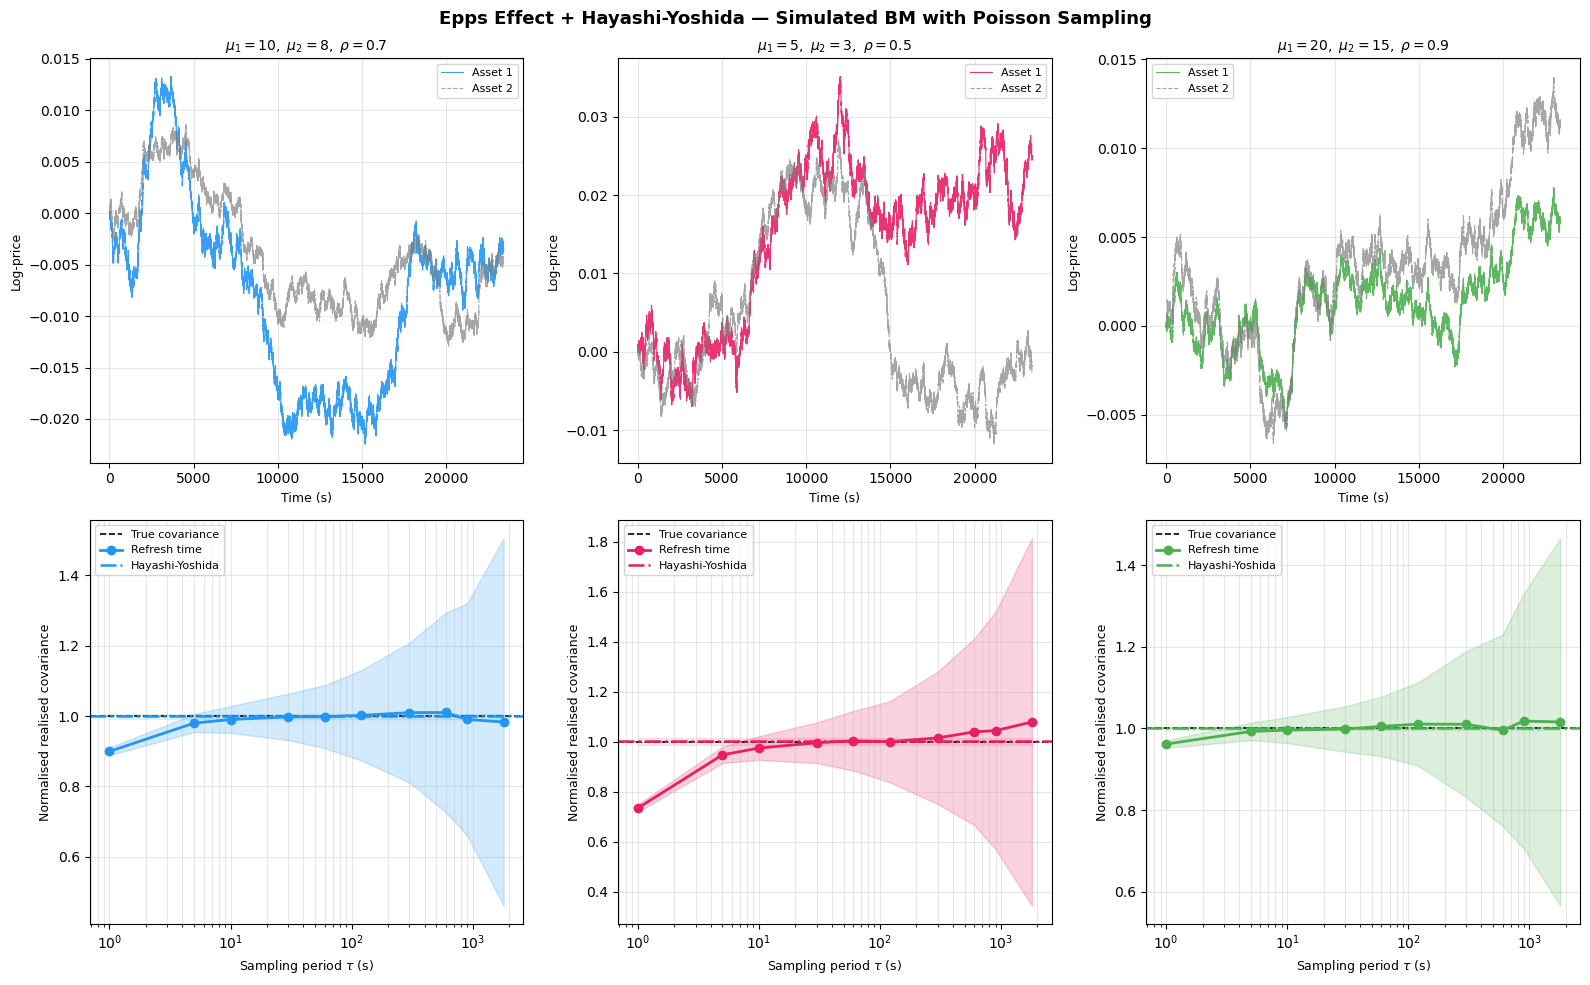

In [8]:
colors = ["#2196F3", "#E91E63", "#4CAF50"]
labels = [
    r"$\mu_1=10,\ \mu_2=8,\ \rho=0.7$",
    r"$\mu_1=5,\ \mu_2=3,\ \rho=0.5$",
    r"$\mu_1=20,\ \mu_2=15,\ \rho=0.9$",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, (res, color, label, (t1, p1, t2, p2)) in enumerate(
        zip(results, colors, labels, sample_paths)):

    ax = axes[0, col]
    ax.plot(t1, p1, color=color, linewidth=0.8, alpha=0.9, label="Asset 1")
    ax.plot(t2, p2, color="gray", linewidth=0.8, alpha=0.7, linestyle="--", label="Asset 2")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Time (s)", fontsize=9)
    ax.set_ylabel("Log-price", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    hy_norm     = res["hy_mean"] / res["true_cov"]
    hy_std_norm = res["hy_std"]  / res["true_cov"]

    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="True covariance")

    ax.plot(TAUS, res["norm_mean"], marker="o", color=color,
            linewidth=2, label="Refresh time")
    ax.fill_between(
        TAUS,
        (res["mean_est"] - res["std_est"]) / res["true_cov"],
        (res["mean_est"] + res["std_est"]) / res["true_cov"],
        alpha=0.2, color=color
    )

    ax.axhline(hy_norm, color=color, linestyle="-.", linewidth=1.8,
               label="Hayashi-Yoshida")
    ax.fill_between(TAUS, hy_norm - hy_std_norm, hy_norm + hy_std_norm,
                    alpha=0.1, color=color)

    ax.set_xscale("log")
    ax.set_xlabel(r"Sampling period $\tau$ (s)", fontsize=9)
    ax.set_ylabel("Normalised realised covariance", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Epps Effect + Hayashi-Yoshida — Simulated BM with Poisson Sampling",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The refresh-time estimator shows the Epps effect:  at small $\tau$, the covariance is underestimated. When $\tau$ increases, it gets closer to the true value.

The bias is strongest in simulation 2 ($\mu_1=5$, $\mu_2=3$), because the trading speeds are very different. The method loses a lot of data from the faster asset, which increases the bias.

In contrast, the Hayashi–Yoshida (HY) estimator is almost unbiased for all $\tau$. It stays close to the true covariance because it uses all asynchronous data. It is also more stable (lower variance), especially for small $\tau$.

In simulation 3 ($\mu_1=20$, $\mu_2=15$), the Epps effect is small. When both assets trade a lot and at similar speeds, the bias almost disappears.

---
---
## 2. Signature plots and Epps effect

Firstly, we prepare log-prices and extract times

In [9]:
STOCKS = [0, 1, 2]
DAYS   = [0, 1, 2]
TAUS   = np.array([1, 5, 10, 30, 60, 120, 300, 600, 900, 1800])

def open_convert_data(name):
    df = pd.read_csv(f"Data/{name}", index_col="ts")
    df.index = pd.to_datetime(df.index)
    return df

def get_log_price_times(df):
    t = (df.index - df.index[0]).total_seconds().values
    p = np.log(df["price"].values)
    return t, p

Now we can compute the estimators

In [10]:
def realised_variance_ticks(p, n_ticks):
    p_sub = p[::n_ticks]
    return float(np.sum(np.diff(p_sub) ** 2))

def realised_cov_ticks(p1, p2_sync, n_ticks):
    p1_sub = p1[::n_ticks]
    p2_sub = p2_sync[::n_ticks]
    return float(np.sum(np.diff(p1_sub) * np.diff(p2_sub)))

def sync_previous_tick(t_ref, t_obs, p_obs):
    idx = np.searchsorted(t_obs, t_ref, side='right') - 1
    idx = np.clip(idx, 0, len(p_obs) - 1)
    return p_obs[idx]

def hayashi_yoshida(t1, p1, t2, p2):
    if len(t1) < 2 or len(t2) < 2:
        return np.nan
    s1, e1, dp1 = t1[:-1], t1[1:], np.diff(p1)
    s2, e2, dp2 = t2[:-1], t2[1:], np.diff(p2)
    n1, n2      = len(dp1), len(dp2)
    result      = 0.0
    j_start     = 0
    for i in range(n1):
        while j_start < n2 and e2[j_start] <= s1[i]:
            j_start += 1
        j = j_start
        while j < n2 and s2[j] < e1[i]:
            result += dp1[i] * dp2[j]
            j += 1
    return result

With the tree types of estimators, we can compute signature plots (variance) and Epps (correlation) for each stock per day also

In [11]:
STOCKS = [0, 1, 2]
DAYS   = [0, 1, 2]
PAIRS  = list(itertools.combinations(STOCKS, 2))
TAUS_TICKS  = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000])


all_dfs = {}
for s in STOCKS:
    for d in DAYS:
        key          = f"Stock{s}_day{d}"
        all_dfs[key] = open_convert_data(f"stock{s}_day{d}_trades.csv.gz")

rv_ticks = {s: np.full((len(TAUS_TICKS), len(DAYS)), np.nan) for s in STOCKS}
rv_hy    = {s: np.full(len(DAYS), np.nan)                    for s in STOCKS}

for s in STOCKS:
    for d in DAYS:
        t, p = get_log_price_times(all_dfs[f"Stock{s}_day{d}"])
        for ti, n in enumerate(TAUS_TICKS):
            rv_ticks[s][ti, d] = realised_variance_ticks(p, n)
        rv_hy[s][d] = hayashi_yoshida(t, p, t, p)

corr_ticks = {pair: np.full((len(TAUS_TICKS), len(DAYS)), np.nan) for pair in PAIRS}
corr_hy    = {pair: np.full(len(DAYS), np.nan)                    for pair in PAIRS}

for (s1, s2) in PAIRS:
    for d in DAYS:
        t1, p1 = get_log_price_times(all_dfs[f"Stock{s1}_day{d}"])
        t2, p2 = get_log_price_times(all_dfs[f"Stock{s2}_day{d}"])

        p2_sync = sync_previous_tick(t1, t2, p2)

        for ti, n in enumerate(TAUS_TICKS):
            cov   = realised_cov_ticks(p1, p2_sync, n)
            rv1   = rv_ticks[s1][ti, d]
            rv2   = rv_ticks[s2][ti, d]
            denom = np.sqrt(rv1 * rv2)
            corr_ticks[(s1, s2)][ti, d] = cov / denom if denom > 0 else np.nan

        cov_hy   = hayashi_yoshida(t1, p1, t2, p2)
        denom_hy = np.sqrt(rv_hy[s1][d] * rv_hy[s2][d])
        corr_hy[(s1, s2)][d] = cov_hy / denom_hy if denom_hy > 0 else np.nan

Then now we plot Signature plot and Epps effect, all by stock

For better readability, we show each day in light gray, and we plot one average curve on top (solid line).

This is because plotting all three days with different styles made the graph hard to read due to overlapping lines.

The average curve keeps the main information and makes the peak easier to see.

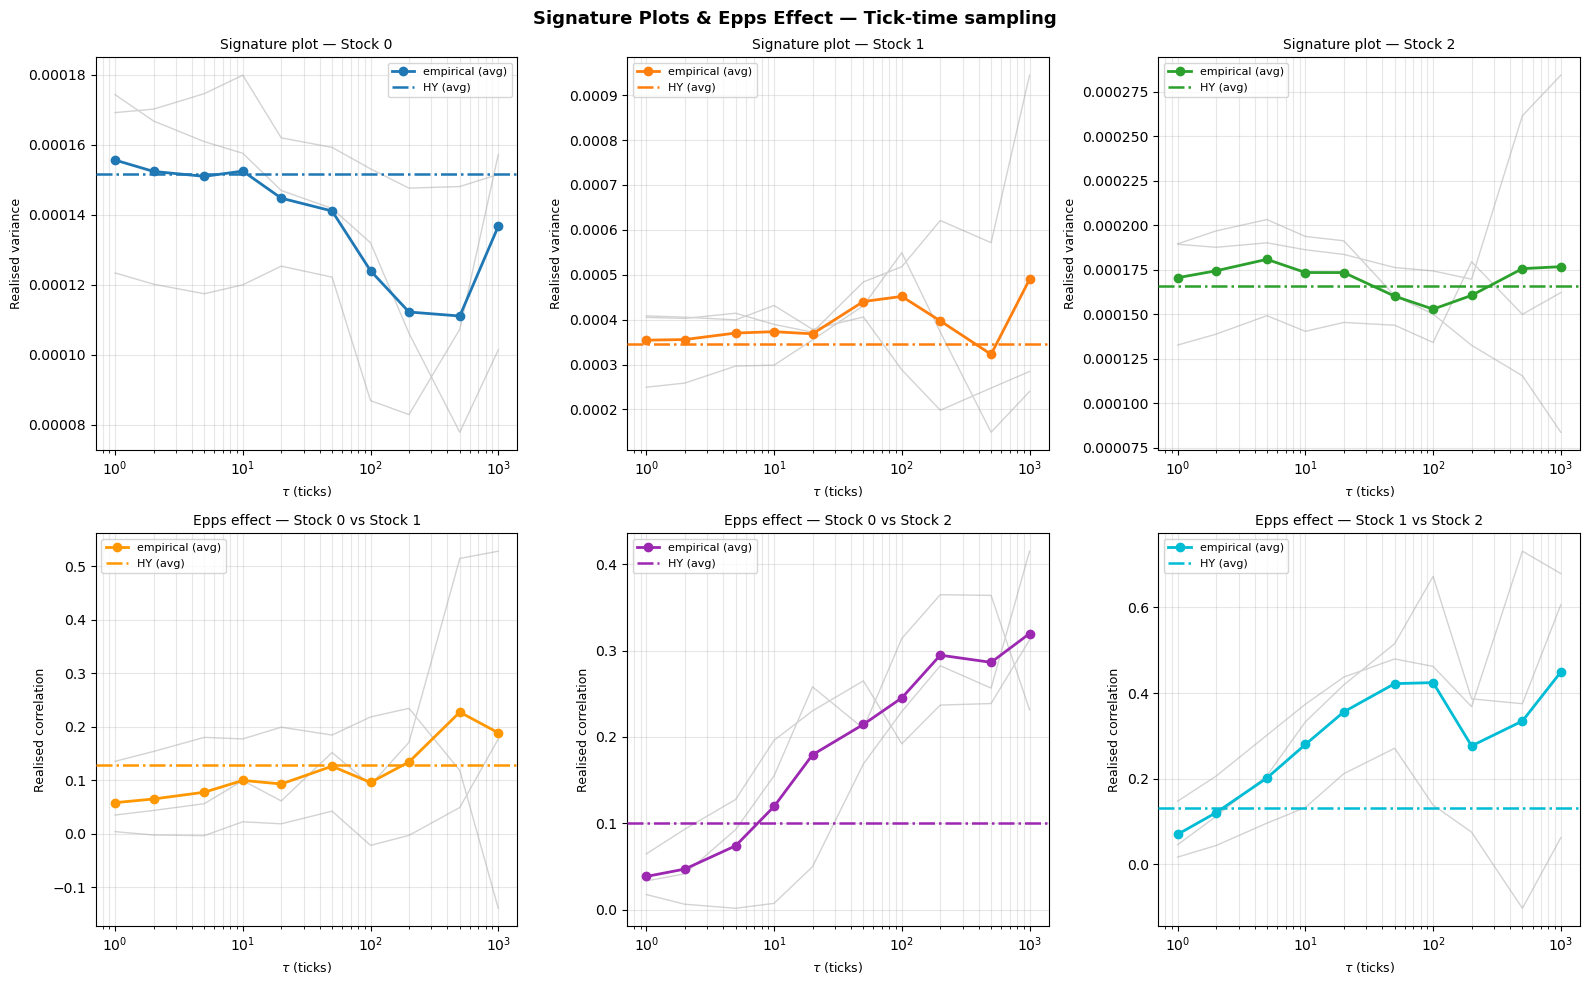

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
pair_colors = ["#FF9800", "#9C27B0", "#00BCD4"]

for s in STOCKS:
    ax  = axes[0, s]
    for d in DAYS:
        ax.plot(TAUS_TICKS, rv_ticks[s][:, d], color="lightgray", linewidth=1, zorder=1)
    avg = np.nanmean(rv_ticks[s], axis=1)
    ax.plot(TAUS_TICKS, avg, marker="o", linewidth=2, color=f"C{s}",
            zorder=2, label="empirical (avg)")
    ax.axhline(np.nanmean(rv_hy[s]), color=f"C{s}", linestyle="-.",
               linewidth=1.8, zorder=3, label="HY (avg)")
    ax.set_xscale("log")
    ax.set_title(f"Signature plot — Stock {s}", fontsize=10)
    ax.set_xlabel(r"$\tau$ (ticks)", fontsize=9)
    ax.set_ylabel("Realised variance", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

for pi, (s1, s2) in enumerate(PAIRS):
    ax = axes[1, pi]
    for d in DAYS:
        ax.plot(TAUS_TICKS, corr_ticks[(s1, s2)][:, d], color="lightgray",
                linewidth=1, zorder=1)
    avg = np.nanmean(corr_ticks[(s1, s2)], axis=1)
    ax.plot(TAUS_TICKS, avg, marker="o", linewidth=2, color=pair_colors[pi],
            zorder=2, label="empirical (avg)")
    ax.axhline(np.nanmean(corr_hy[(s1, s2)]), color=pair_colors[pi],
               linestyle="-.", linewidth=1.8, zorder=3, label="HY (avg)")
    ax.set_xscale("log")
    ax.set_title(f"Epps effect — Stock {s1} vs Stock {s2}", fontsize=10)
    ax.set_xlabel(r"$\tau$ (ticks)", fontsize=9)
    ax.set_ylabel("Realised correlation", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Signature Plots & Epps Effect — Tick-time sampling",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()




Signature plots in tick-time show the usual microstructure noise effect.  
At very high frequency, the realized variance is too high because of effects like the bid-ask bounce.  
When we increase $\tau$, the variance decreases and gets closer to the Hayashi–Yoshida (HY) reference value.

We also observe the Epps effect for all three pairs.  
The standard realized correlations are strongly underestimated at very high frequency ($\tau = 1$ tick).  
As $\tau$ increases ($\tau \geq 100$ ticks), the correlations rise and converge toward the HY estimate.

This means that asynchronous trading reduces the measured correlations at very fine time scales.

---
---
## 3. Lead-lag estimation

For each lag $\theta$, we compute the Hayashi-Yoshida lead-lag estimator:

$$
HY(\theta) = \sum dp1_i \cdot dp2_j \cdot \mathbf{1}\left(I^1_i \cap I^2_j(\theta) \neq \varnothing\right)
$$

where the interval of asset 2 is shifted by the lag $\theta$:

$$
I^2_j(\theta) = [s^2_j + \theta,\; e^2_j + \theta]
$$

The estimated lead-lag relationship corresponds to the lag that maximizes the absolute value of the estimator:

$$
\hat{\theta} = \arg\max_{\theta} |HY(\theta)|
$$

In [13]:
def hy_lead_lag(t1, p1, t2, p2, lags_seconds):

    if len(t1) < 2 or len(t2) < 2:
        return np.full(len(lags_seconds), np.nan)

    s1, e1, dp1 = t1[:-1], t1[1:], np.diff(p1)
    s2, e2, dp2 = t2[:-1], t2[1:], np.diff(p2)
    n1, n2      = len(dp1), len(dp2)
    results     = np.full(len(lags_seconds), np.nan)

    for li, theta in enumerate(lags_seconds):
        s2s = s2 + theta
        e2s = e2 + theta
        result  = 0.0
        j_start = 0
        for i in range(n1):
            while j_start < n2 and e2s[j_start] <= s1[i]:
                j_start += 1
            j = j_start
            while j < n2 and s2s[j] < e1[i]:
                result += dp1[i] * dp2[j]
                j += 1
        results[li] = result

    return results

Then for each pair and for each day,

In [14]:
LAGS = np.arange(-60, 61, 1)

hy_ll = {pair: np.full((len(LAGS), len(DAYS)), np.nan) for pair in PAIRS}

for (s1, s2) in PAIRS:
    for d in DAYS:
        t1, p1 = get_log_price_times(all_dfs[f"Stock{s1}_day{d}"])
        t2, p2 = get_log_price_times(all_dfs[f"Stock{s2}_day{d}"])
        hy_ll[(s1, s2)][:, d] = hy_lead_lag(t1, p1, t2, p2, LAGS)

Now we plot to commpare:

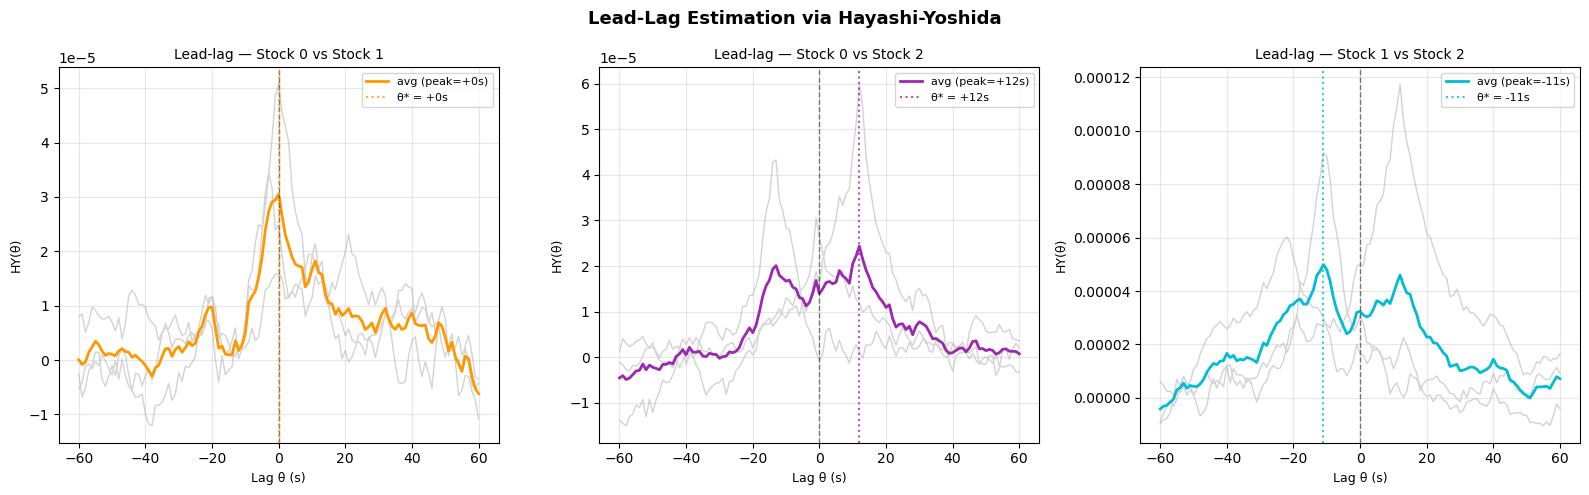

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pair_colors = ["#FF9800", "#9C27B0", "#00BCD4"]

for pi, (s1, s2) in enumerate(PAIRS):
    ax = axes[pi]

    # 3 jours en gris en arrière-plan
    for d in DAYS:
        ax.plot(LAGS, hy_ll[(s1, s2)][:, d], color="lightgray", linewidth=1, zorder=1)

    # moyenne sur les jours en couleur
    avg      = np.nanmean(hy_ll[(s1, s2)], axis=1)
    best_lag = LAGS[np.argmax(np.abs(avg))]
    ax.plot(LAGS, avg, linewidth=2, color=pair_colors[pi], zorder=2,
            label=f"avg (peak={best_lag:+.0f}s)")

    ax.axvline(0,        color="black",         linestyle="--", linewidth=1,   alpha=0.5)
    ax.axvline(best_lag, color=pair_colors[pi], linestyle=":",  linewidth=1.5, alpha=0.8,
               label=f"θ* = {best_lag:+.0f}s")

    ax.set_title(f"Lead-lag — Stock {s1} vs Stock {s2}", fontsize=10)
    ax.set_xlabel("Lag θ (s)", fontsize=9)
    ax.set_ylabel("HY(θ)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Lead-Lag Estimation via Hayashi-Yoshida", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#print("\nLag estimé (argmax |HY(θ)|) sur la moyenne :")
#for (s1, s2) in PAIRS:
#    avg      = np.nanmean(hy_ll[(s1, s2)], axis=1)
#    best_lag = LAGS[np.argmax(np.abs(avg))]
#    print(f"  Stock{s1} vs Stock{s2} : θ* = {best_lag:+.0f} s")

The lead-lag results are different for each pair.

For Stock 0 vs Stock 1, there is no clear lead-lag effect. The curve is flat around 0 and peaks at $\theta = 0$, so both stocks move at the same time.

For the two others plots, we see a clear peak near 0. This shows a lead-lag relationship:
- Stock 2 leads Stock 0 by about 12 seconds.
- Stock 1 leads Stock 2 by about 11 seconds.

---
---
## 4. A Hawkes process for trades

For this part, our procedure will rely on the following reference : LOB modeling using Hawkes processes with a state-dependent factor from Sfendourakis and Toke.

The paper propose a new Hawkes Model called : msdHawkes

$\lambda(t) = \lambda_H(t) \times exp(\langle \theta, X_t \rangle)$

Where :
- $\lambda_H(t)$ is the standard Hawkes
- $X_t$ is a state variable
- $\theta$ : coefficients

Hawkes capture clustering of trades while state factors capture market conditions

### Classical Hawkes Model

We will try with a classical Hawkes model then extend to the msdHawkes but the important point is that we will follow the procedure of fitting presented in section 3 of the paper and use the equations of Likelihood and EM presented in this paper.

In [16]:
def open_convert_data(name : str) -> pd.DataFrame :
    df = pd.read_csv(f"Data/{name}", index_col="ts")
    df.index = pd.to_datetime(df.index)
    return df

For this part we use the trades files

In [17]:
df0_j0 = open_convert_data("stock0_day0_trades.csv.gz")
df0_j1 = open_convert_data("stock0_day1_trades.csv.gz")
df0_j2 = open_convert_data("stock0_day2_trades.csv.gz")

df1_j0 = open_convert_data("stock1_day0_trades.csv.gz")
df1_j1 = open_convert_data("stock1_day1_trades.csv.gz")
df1_j2 = open_convert_data("stock1_day2_trades.csv.gz")

df2_j0 = open_convert_data("stock2_day0_trades.csv.gz")
df2_j1 = open_convert_data("stock2_day1_trades.csv.gz")
df2_j2 = open_convert_data("stock2_day2_trades.csv.gz")

We conver the timestamps to use the events times

In [18]:
def datetime_to_seconds(df):
    times = df.index.astype('int64') / 1e9
    times = times - times[0]
    return np.array(times)

In [19]:
datasets = {
    "stock0_day0": df0_j0,
    "stock0_day1": df0_j1,
    "stock0_day2": df0_j2,
    "stock1_day0": df1_j0,
    "stock1_day1": df1_j1,
    "stock1_day2": df1_j2,
    "stock2_day0": df2_j0,
    "stock2_day1": df2_j1,
    "stock2_day2": df2_j2,
}

Here is the likelihood estimator for Hawkes Process

In [20]:
def hawkes_loglik(params, timestamps):
    mu, alpha, beta = params

    if mu <= 0 or alpha <= 0 or beta <= 0:
        return np.inf

    T = timestamps[-1]
    n = len(timestamps)

    intensity = np.zeros(n)

    for i in range(n):
        t = timestamps[i]
        past = timestamps[:i]
        intensity[i] = mu + np.sum(alpha * np.exp(-beta * (t - past)))

    loglik = np.sum(np.log(intensity))

    integral = mu * T
    for t_i in timestamps:
        integral += (alpha / beta) * (1 - np.exp(-beta * (T - t_i)))

    return -(loglik - integral)

In [21]:
def fit_hawkes(timestamps):
    init = np.array([0.1, 0.5, 1.0])

    res = minimize(
        hawkes_loglik,
        init,
        args=(timestamps,),
        method='L-BFGS-B',
        bounds=[(1e-6, None), (1e-6, None), (1e-6, None)]
    )

    return res.x

In [22]:
def compute_residuals(timestamps, mu, alpha, beta):
    residuals = []

    for i in range(len(timestamps) - 1):
        t0, t1 = timestamps[i], timestamps[i+1]

        grid = np.linspace(t0, t1, 20)
        lambda_vals = [
            mu + np.sum(alpha * np.exp(-beta * (t - timestamps[timestamps < t])))
            for t in grid
        ]

        integral = np.trapz(lambda_vals, grid)
        residuals.append(integral)

    return np.array(residuals)

In [23]:
def evaluate_model(residuals):
    stat, p_value = kstest(residuals, 'expon')
    return stat, p_value

In [24]:
def poisson_rate(timestamps):
    T = timestamps[-1]
    return len(timestamps) / T

In [25]:
results = {}

for name, df in datasets.items():

    timestamps = datetime_to_seconds(df)

    mu, alpha, beta = fit_hawkes(timestamps)

    residuals = compute_residuals(timestamps, mu, alpha, beta)

    stat, p_value = evaluate_model(residuals)

    lambda_pois = poisson_rate(timestamps)

    results[name] = {
        "mu": mu,
        "alpha": alpha,
        "beta": beta,
        "branching_ratio": alpha / beta,
        "KS_stat": stat,
        "p_value": p_value,
        "poisson_lambda": lambda_pois,
        'residuals' : residuals
    }

/var/folders/nk/kpj6413n2lj1cln9c1z0_pj80000gn/T/ipykernel_5023/574038745.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(lambda_vals, grid)
/var/folders/nk/kpj6413n2lj1cln9c1z0_pj80000gn/T/ipykernel_5023/574038745.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(lambda_vals, grid)
/var/folders/nk/kpj6413n2lj1cln9c1z0_pj80000gn/T/ipykernel_5023/574038745.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(lambda_vals, grid)
/var/folders/nk/kpj6413n2lj1cln9c1z0_pj80000gn/T/ipykernel_5023/574038745.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integra

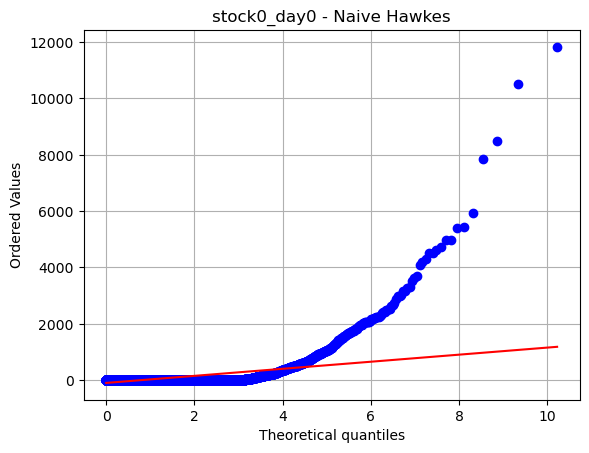

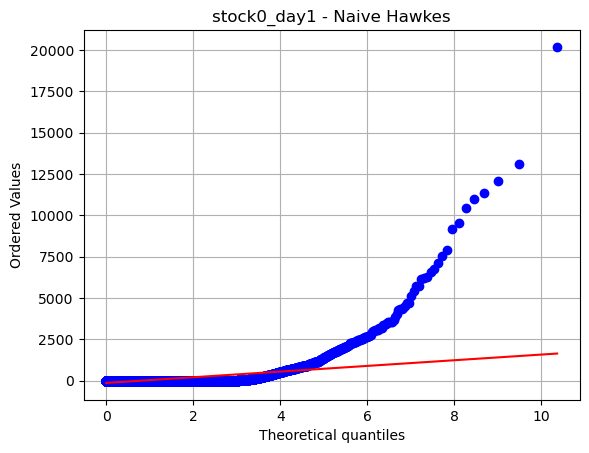

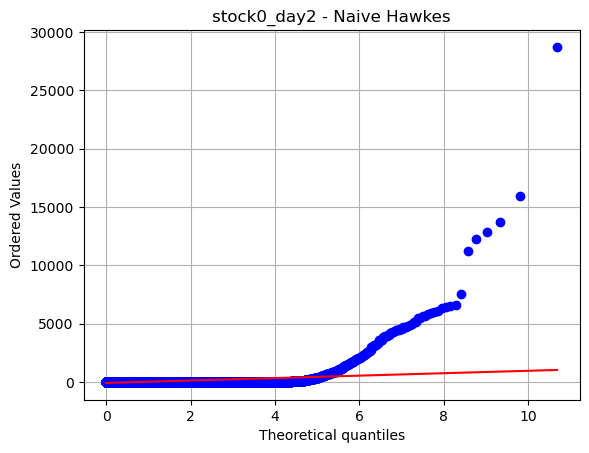

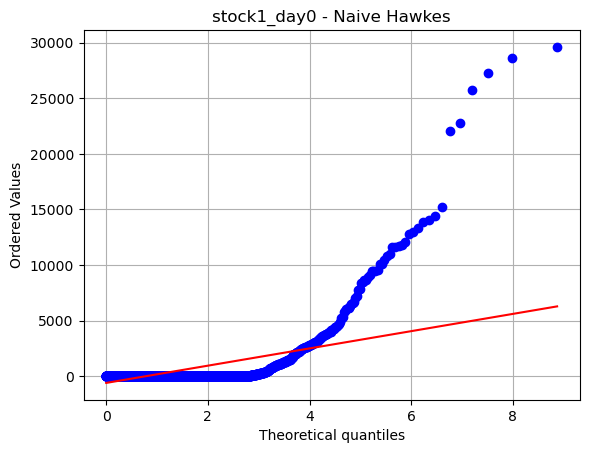

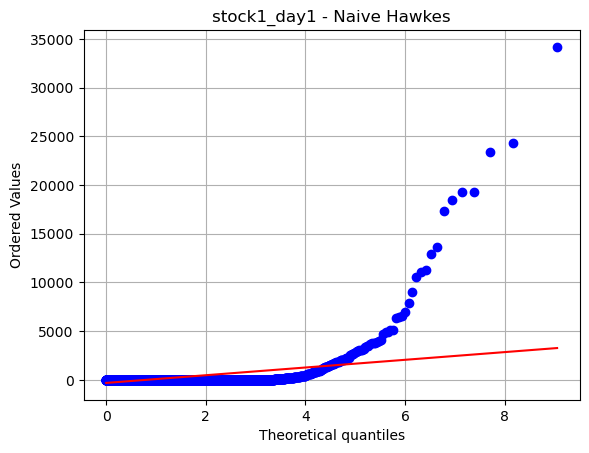

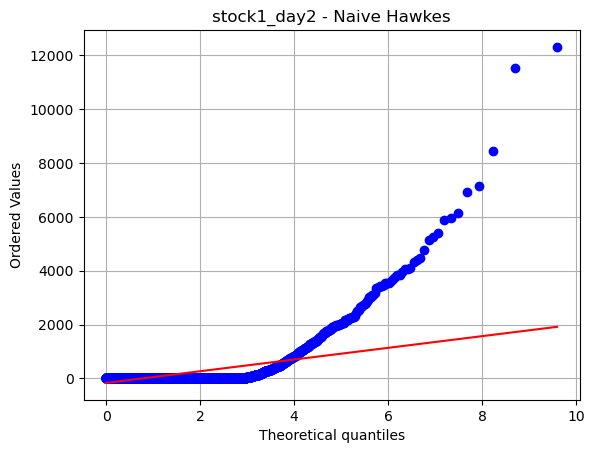

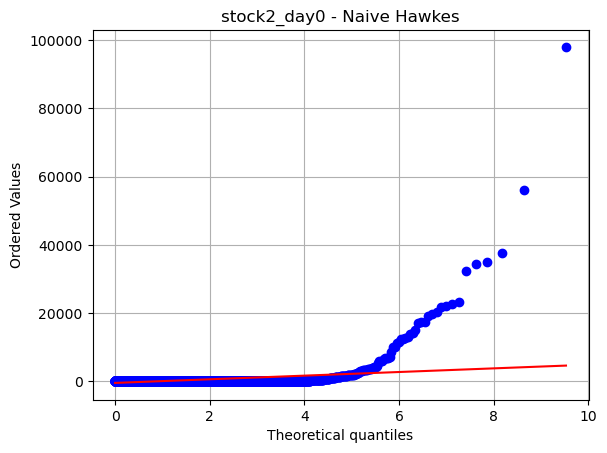

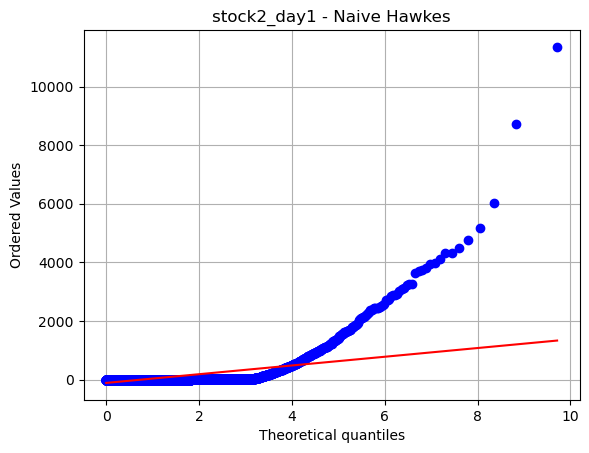

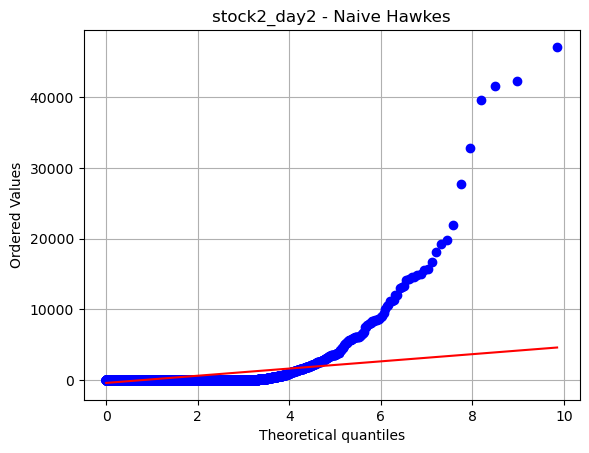

In [26]:
def qq_plot_exponential(residuals, title="QQ Plot"):
    stats.probplot(residuals, dist="expon", plot=plt)
    plt.title(title)
    plt.grid(True)
    plt.show()

for name, df in datasets.items():
    qq_plot_exponential(results[name]["residuals"], title=f"{name} - Naive Hawkes")

What does this results says :

- The estimated branching ratios between 0.5 and 0.8 indicate strong endogenous activity, meaning that a large fraction of trades are triggered by previous trades.
- The baseline intensity is significantly lower than the Poisson rate, indicating that most trades are endogenously generated.
- While the Hawkes process successfully captures the clustering of trades, the time-change residual analysis strongly rejects the model, indicating that it fails to fully explain the dynamics of the data.

That's why, we will try to implement a state dependant model as in the paper cited above.

### State Dependant Hawkes Model

We will use the imbalance as a feature to feed our new model

In [27]:
def compute_imbalance(df):
    return (df["bq"] - df["aq"]) / (df["bq"] + df["aq"])

To use the above function, we need to use the updates files this time

In [28]:
df0_j0 = open_convert_data("stock0_day0_updates.csv.gz")
df0_j1 = open_convert_data("stock0_day1_updates.csv.gz")
df0_j2 = open_convert_data("stock0_day2_updates.csv.gz")

df1_j0 = open_convert_data("stock1_day0_updates.csv.gz")
df1_j1 = open_convert_data("stock1_day1_updates.csv.gz")
df1_j2 = open_convert_data("stock1_day2_updates.csv.gz")

df2_j0 = open_convert_data("stock2_day0_updates.csv.gz")
df2_j1 = open_convert_data("stock2_day1_updates.csv.gz")
df2_j2 = open_convert_data("stock2_day2_updates.csv.gz")

In [29]:
datasets = {
    "stock0_day0": df0_j0,
    "stock0_day1": df0_j1,
    "stock0_day2": df0_j2,
    "stock1_day0": df1_j0,
    "stock1_day1": df1_j1,
    "stock1_day2": df1_j2,
    "stock2_day0": df2_j0,
    "stock2_day1": df2_j1,
    "stock2_day2": df2_j2,
}

In [30]:
def prepare_data(df):
    df = df[df['type']=="T"].copy()
    timestamps = df.index.astype('int64') / 1e9
    timestamps = timestamps - timestamps[0]

    imbalance = compute_imbalance(df).values

    return timestamps, imbalance

In this part the difficulty comes from the fact that we need to compute

$\int ^T _O \lambda(t) dt$

with

$\lambda(t) = \lambda_H(t) \times exp(\langle \theta, X_t \rangle)$

The proble is that $X_t$ changes over time and the intensity is note picewise simple.

The paper propose a reccursive Hawkes Structure as following

$R_i = exp(-\beta(t_i - t_{i-1})) \times (1 + R_{i-1})$

In [31]:
def compute_R(timestamps, beta):
    R = np.zeros(len(timestamps))

    for i in range(1, len(timestamps)):
        dt = timestamps[i] - timestamps[i-1]
        R[i] = np.exp(-beta * dt) * (1 + R[i-1])

    return R

The intensity becomes so $\lambda_i = (\mu + \alpha R_i)exp(\theta X_i)$

In [32]:
def loglik_hawkes_state(params, t, X):
    mu, alpha, beta, theta = params

    if mu <= 0 or alpha <= 0 or beta <= 0:
        return np.inf

    R = compute_R(t, beta)

    lam = (mu + alpha * R) * np.exp(theta * X)

    loglik = np.sum(np.log(lam))

    compensator = 0.0

    for i in range(len(t) - 1):
        dt = t[i+1] - t[i]

        x = X[i]
        factor = np.exp(theta * x)

        compensator += factor * (
            mu * dt +
            (alpha / beta) * (1 - np.exp(-beta * dt)) * (1 + R[i])
        )

    return -(loglik - compensator)

In [33]:
def fit_model(t, X):
    init = np.array([0.1, 0.5, 1.0, 0.0])

    res = minimize(
        loglik_hawkes_state,
        init,
        args=(t, X),
        method='L-BFGS-B',
        bounds=[
            (1e-6, 5),
            (1e-6, 5),
            (1e-6, 10),
            (-5, 5)
        ]
    )

    return res.x

This implementation is closely aligned with the methodology proposed in the paper and leads to significantly more stable parameter estimates.

In [34]:
results_3 = {}

for name, df in datasets.items():
    print(f"Processing {name}")

    timestamps, X = prepare_data(df)

    X = (X - np.mean(X)) / np.std(X)

    mu, alpha, beta, theta = fit_model(timestamps, X)

    results_3[name] = {
        "mu": mu,
        "alpha": alpha,
        "beta": beta,
        "theta": theta,
        "branching_ratio": alpha / beta
    }

Processing stock0_day0
Processing stock0_day1
Processing stock0_day2
Processing stock1_day0
Processing stock1_day1
Processing stock1_day2
Processing stock2_day0
Processing stock2_day1
Processing stock2_day2


In [35]:
def compute_residuals_state(t, X, mu, alpha, beta, theta):
    R = compute_R(t, beta)
    residuals = []

    for i in range(len(t) - 1):
        dt = t[i+1] - t[i]
        x = X[i]

        factor = np.exp(theta * x)

        integral = factor * (
            mu * dt +
            (alpha / beta) * (1 - np.exp(-beta * dt)) * (1 + R[i])
        )

        residuals.append(integral)

    return np.array(residuals)

In [36]:
def qq_plot_exponential(residuals, title="QQ Plot"):
    stats.probplot(residuals, dist="expon", plot=plt)
    plt.title(title)
    plt.grid(True)
    plt.show()

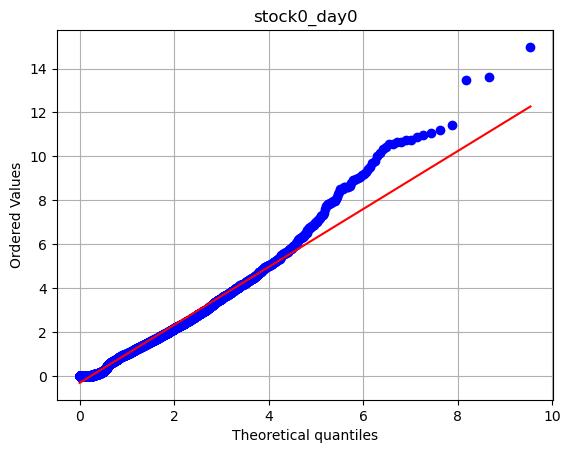

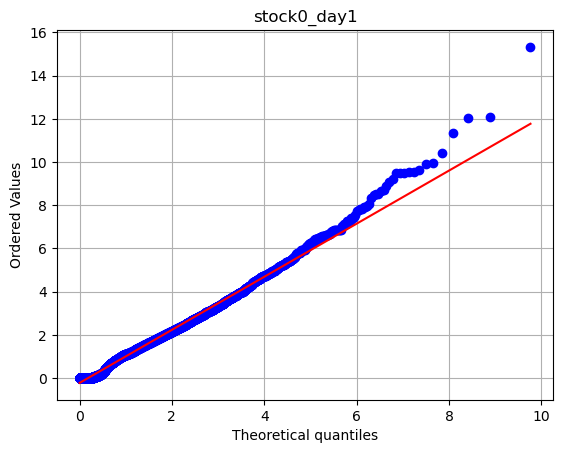

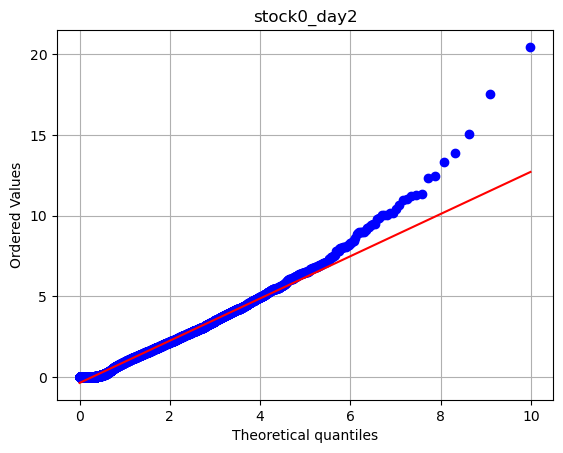

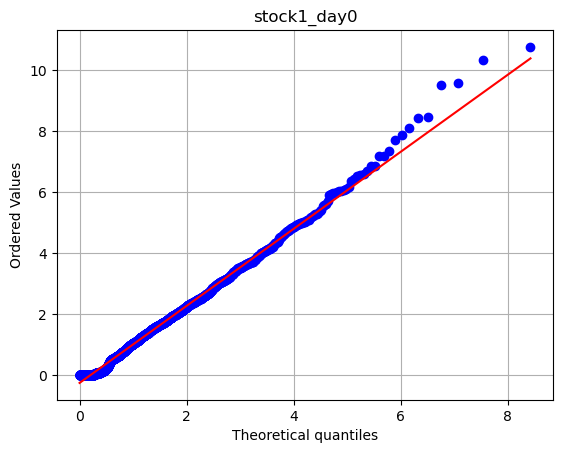

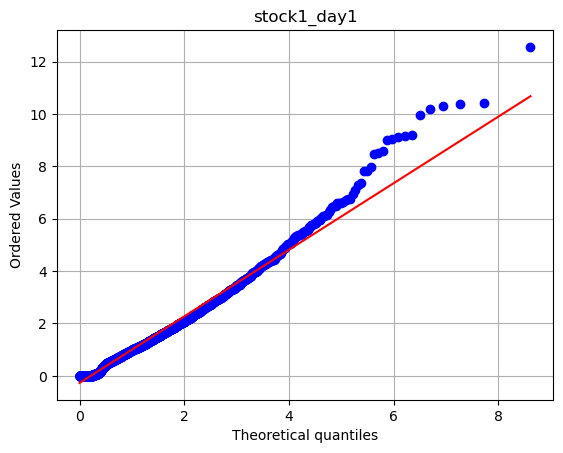

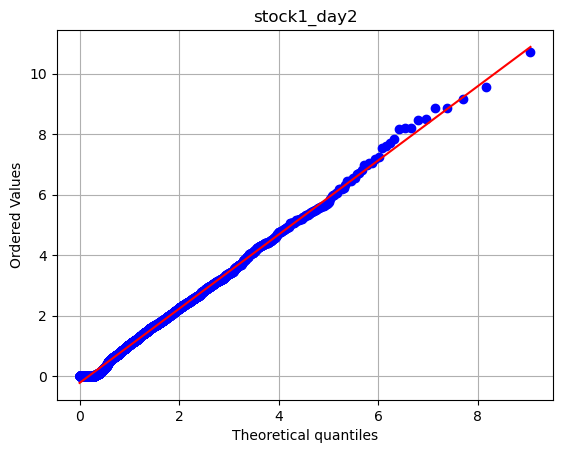

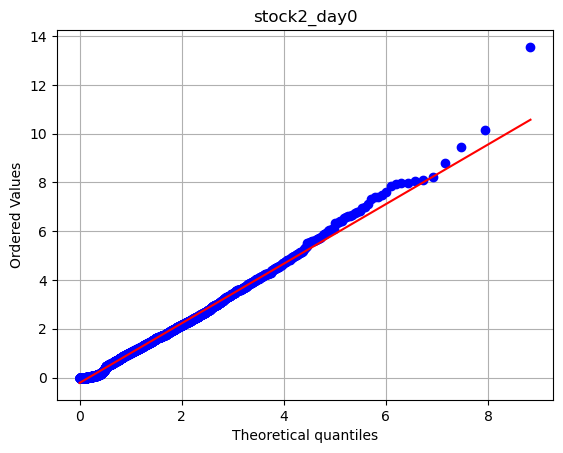

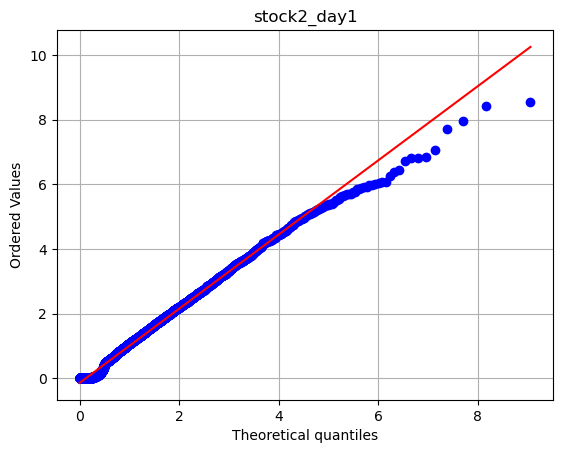

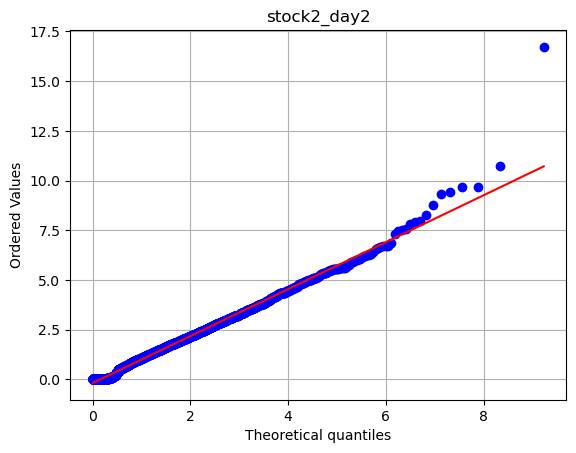

In [37]:
for name, df in datasets.items():

    t, X = prepare_data(df)
    mu, alpha, beta, theta = fit_model(t, X)

    residuals = compute_residuals_state(t, X, mu, alpha, beta, theta)

    qq_plot_exponential(residuals, title=name)

We clearly see an improvement from the previous model. Adding a state space variable into our modelisation, here the imbalance, improve the goodness of fit of our modelisation and seems more aligned with the reality.

To finally answer the question Hawkes process is not a good model for the time dynamics for of our trades data but a state dependant model gives better results. A drawback for the second model is his complexity to implement. We rellied on a research paper but proposed an approximation of the method detailed in the research while the real algorithm was too complex to implement.

The complexity of this kind of model gives the researcher a modelling choice at the begining to chose which feature he wants to use to model his time dynamics. Adding multiple features is possible but also add complexity in the interpretability of the results.

---
---
## 5. Hawkes fit on signature plots

In this section we will use the model provided in section 2 of the paper Modeling microstructure noise with mutually exciting point processes proposed by Bacry, Delattre, Hoffmann and Muzy

The price model is the following :

$X(t) = N_1(t) - N_2(t)$

- N_1 are upward jumps
- N_2 are downward jumps

with the following Hawkes intensities

$\lambda_1(t) = \mu + \int \phi(t-s)dN_2(s)$

$\lambda_12t) = \mu + \int \phi(t-s)dN_1(s)$

As usual the ususal exponential kernel $\phi(t) = \alpha e^{-\beta t} \mathbb{1}_{t>0}$

With the parameters to estimate $\theta = (\mu, \alpha, \beta)$

with the constraint : $\frac{\alpha}{\beta} < 1$

We want to estimate from data the empirical signature plot, for each stock

$\hat{C}(\tau) = \frac{1}{T} \sum _n |X((n+1)\tau) - X(n\tau)|^2$

While in case of the mean-reversion Hawkes model, the real formula is

$C(\tau) = \wedge (\kappa ^2 + (1 - \kappa ^2)\frac{1 - e^{-\gamma \tau}}{\gamma \tau}$

In [38]:
df0_j0 = open_convert_data("stock0_day0_trades.csv.gz")
df0_j1 = open_convert_data("stock0_day1_trades.csv.gz")
df0_j2 = open_convert_data("stock0_day2_trades.csv.gz")

df1_j0 = open_convert_data("stock1_day0_trades.csv.gz")
df1_j1 = open_convert_data("stock1_day1_trades.csv.gz")
df1_j2 = open_convert_data("stock1_day2_trades.csv.gz")

df2_j0 = open_convert_data("stock2_day0_trades.csv.gz")
df2_j1 = open_convert_data("stock2_day1_trades.csv.gz")
df2_j2 = open_convert_data("stock2_day2_trades.csv.gz")

In [39]:
datasets = {
    "stock0_day0": df0_j0,
    "stock0_day1": df0_j1,
    "stock0_day2": df0_j2,
    "stock1_day0": df1_j0,
    "stock1_day1": df1_j1,
    "stock1_day2": df1_j2,
    "stock2_day0": df2_j0,
    "stock2_day1": df2_j1,
    "stock2_day2": df2_j2,
}

In [40]:
def get_price_series(df):
    df = df.sort_index()

    prices = df["price"].values

    return prices

We define the estimator for $\hat{C}(\tau)$

In [41]:
def compute_signature_plot(prices, max_lag=500, n_lags=50):
    taus = np.unique(np.logspace(0, np.log10(max_lag), n_lags).astype(int))

    C_tau = []

    for tau in taus:
        if tau >= len(prices):
            continue

        returns = prices[tau:] - prices[:-tau]
        C_tau.append(np.mean(returns**2))

    return taus[:len(C_tau)], np.array(C_tau)

We define the real mean-reversion $C(\tau)$

In [42]:
def C_theoretical(tau, mu, alpha, beta):
    phi_norm = alpha / beta

    if phi_norm >= 1:
        return np.full_like(tau, np.inf)

    Lambda = 2 * mu / (1 - phi_norm)
    kappa = 1 / (1 + phi_norm)
    gamma = alpha + beta

    return Lambda * (
        kappa**2 + (1 - kappa**2) * (1 - np.exp(-gamma * tau)) / (gamma * tau)
    )

We want to fit the parameters using from the paper

$\hat{\theta} = arg min _{\theta} |\hat{C}(\tau) - C(\tau)|^2$

In [43]:
def loss(theta, tau, C_emp):
    mu, alpha, beta = theta

    if mu <= 0 or alpha <= 0 or beta <= 0 or alpha >= beta:
        return 1e10

    C_th = C_theoretical(tau, mu, alpha, beta)

    return np.mean((np.log(C_emp) - np.log(C_th))**2)

In [44]:
def fit_hawkes(tau, C_emp):

    res = minimize(
        loss,
        x0=[0.01, 0.02, 0.1],
        args=(tau, C_emp),
        method="Nelder-Mead"
    )

    return res.x

In [47]:
def signature_plot(prices, max_lag=500, n_lags=50):
    
    taus = np.linspace(1, max_lag, n_lags).astype(int)
    taus = np.unique(taus)
    
    sig = []
    
    for tau in taus:
        if tau >= len(prices):
            continue
        
        increments = prices[tau:] - prices[:-tau]
        
        C_tau = np.mean(increments**2) / tau
        
        sig.append(C_tau)
    
    return taus[:len(sig)], np.array(sig)

In [48]:
def plot_signature_with_fit_per_stock(datasets):

    stock_groups = defaultdict(list)

    for name, df in datasets.items():
        stock = name.split("_")[0]
        stock_groups[stock].append((name, df))

    stocks   = list(stock_groups.keys())
    n_stocks = len(stocks)

    fig, axes = plt.subplots(
        1, n_stocks,
        figsize=(6 * n_stocks, 5),
        constrained_layout=True,
    )

    axes = list(axes) if n_stocks > 1 else [axes]

    for ax, (stock, items) in zip(axes, stock_groups.items()):

        daily_curves = []
        for _, df in sorted(items):
            prices = get_price_series(df)
            tau, C_day = signature_plot(prices)
            daily_curves.append(C_day)

        C_emp = np.mean(daily_curves, axis=0)

        params = fit_hawkes(tau, C_emp)
        C_fit  = C_theoretical(tau, *params)

        line, = ax.plot(tau, C_emp, marker='o', linestyle='-',  label="empirical (avg)")
        ax.plot(tau, C_fit,  linestyle='--', color=line.get_color(), label="fit")

        for C_day in daily_curves:
            ax.plot(tau, C_day, color="gray", alpha=0.2, linewidth=0.8)

        ax.set_title(f"Signature plot + Hawkes fit — {stock}")
        ax.set_xlabel(r'$\tau$')
        ax.set_ylabel(r'$\hat{C}(\tau)$')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.show()

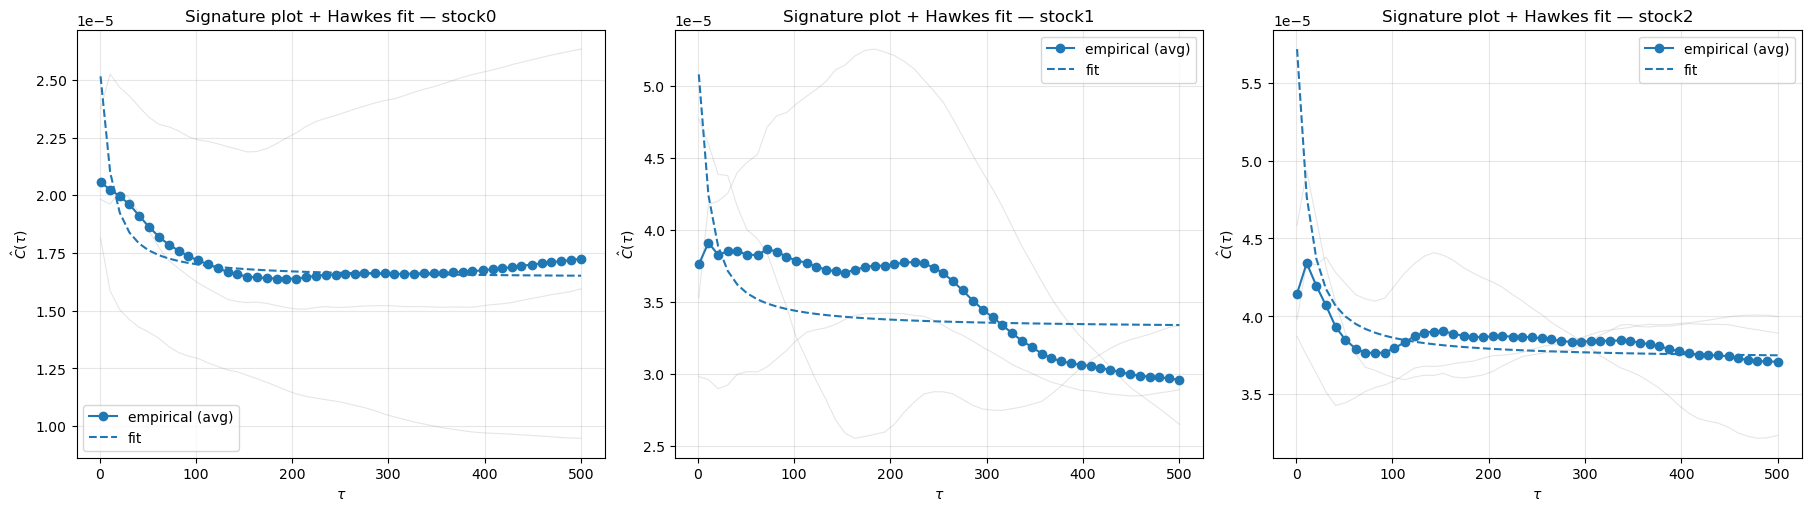

In [49]:
plot_signature_with_fit_per_stock(datasets)

What we observe here is that for some days, the signature plot is quite good (especially for stock 0) while for stock 1 and 2 the fit is quite bad. An explaination to what we visualize is that we didn't restrain our data to a time window as they made in the paper (9h-11h).

Also the model suppose a perfect symmetry between $N_1$ and $N_2$, up and down movements which is not verified in practice. To capture theses oscillations, the bivariate model in section 3 of the paper could be better.

Finally we used an exponential kernel. Maybe using another kernel could lead to better results.

We tried to restrain to the time window evoked above to see if we obtain better results.

In [50]:
def get_price_series(df, start_time="09:00", end_time="11:00"):
    df = df.sort_index()

    if isinstance(df.index, pd.DatetimeIndex):
        df = df.between_time(start_time, end_time)
    else:
        df.index = pd.to_datetime(df.index)
        df = df.between_time(start_time, end_time)

    prices = df["price"].values

    return prices

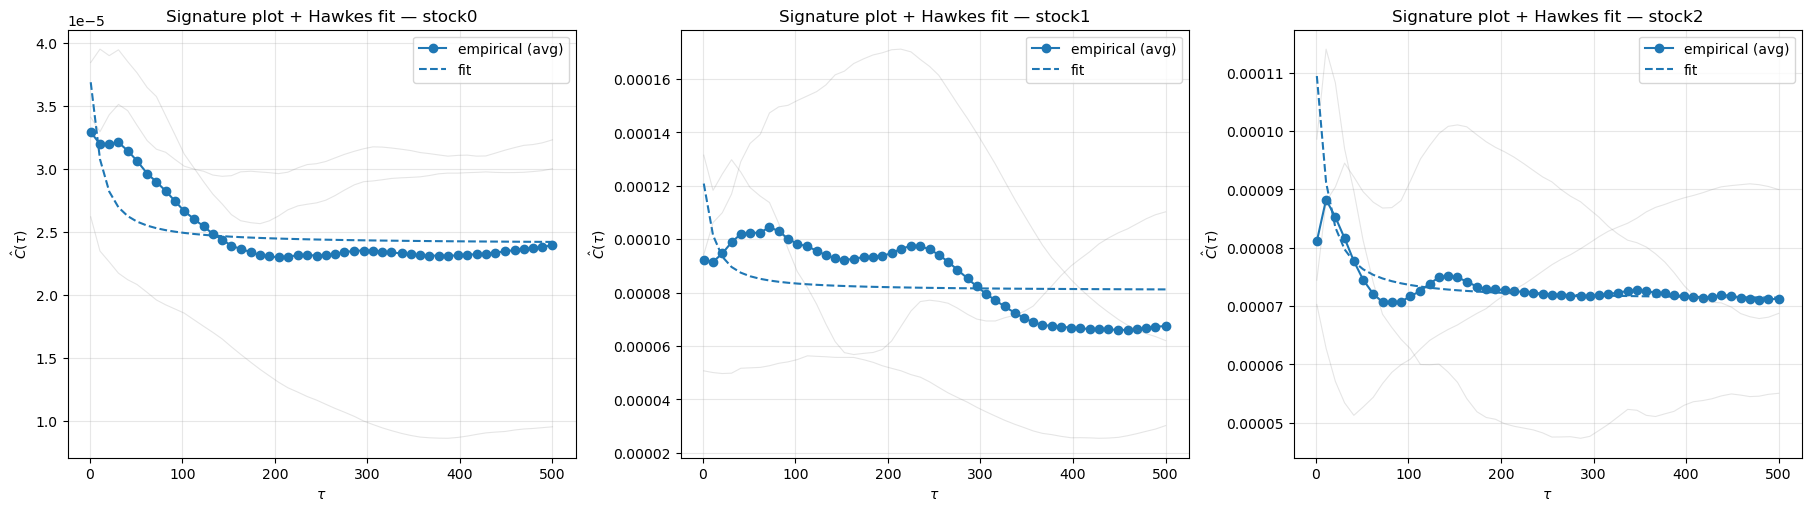

In [51]:
plot_signature_with_fit_per_stock(datasets)

We do not see a big improvements especially for stock 1 which has the worst fit of the three.